In [28]:
import matplotlib.pyplot as plt
import torch 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

generator = torch.Generator().manual_seed(42)

In [20]:
train_dataset = datasets.MNIST(
    root = "../../Datasets",
    train = True,
    transform=transform,
    download=True
)

test_dataset = datasets.MNIST(
    root = "../../Datasets",
    train = False,
    transform=transform,
    download=True
)

train_dataset, val_dataset = random_split(
    train_dataset,
    [54000, 6000],
    generator=generator
)

In [21]:
train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    batch_size=64
)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    batch_size=64
)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    batch_size=1000
)

In [22]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.flatten = nn.Flatten()

        self.fc1 = nn.LazyLinear(128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.flatten(x)

        x = self.fc1(x)
        x = self.relu3(x)
        x = self.fc2(x)

        return x


model = CNN().to(device)

In [23]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [25]:
epochs = 5

for epoch in range(epochs):

    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        predicted = outputs.argmax(dim=1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss /= len(train_loader)
    train_accuracy = train_correct / train_total


    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            predicted = outputs.argmax(dim=1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_accuracy = val_correct / val_total


    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )


Epoch 01/5 | Train Loss: 0.1415 | Train Acc: 0.9560 | Val Loss: 0.0609 | Val Acc: 0.9833
Epoch 02/5 | Train Loss: 0.0444 | Train Acc: 0.9861 | Val Loss: 0.0559 | Val Acc: 0.9817
Epoch 03/5 | Train Loss: 0.0299 | Train Acc: 0.9909 | Val Loss: 0.0396 | Val Acc: 0.9878
Epoch 04/5 | Train Loss: 0.0220 | Train Acc: 0.9929 | Val Loss: 0.0422 | Val Acc: 0.9875
Epoch 05/5 | Train Loss: 0.0160 | Train Acc: 0.9950 | Val Loss: 0.0422 | Val Acc: 0.9883


In [26]:
model.eval()

test_loss = 0.0
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)
        test_loss += loss.item()

        predicted = outputs.argmax(dim=1)

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_loss /= len(test_loader)
test_accuracy = test_correct / test_total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.0303
Test Accuracy: 0.9905


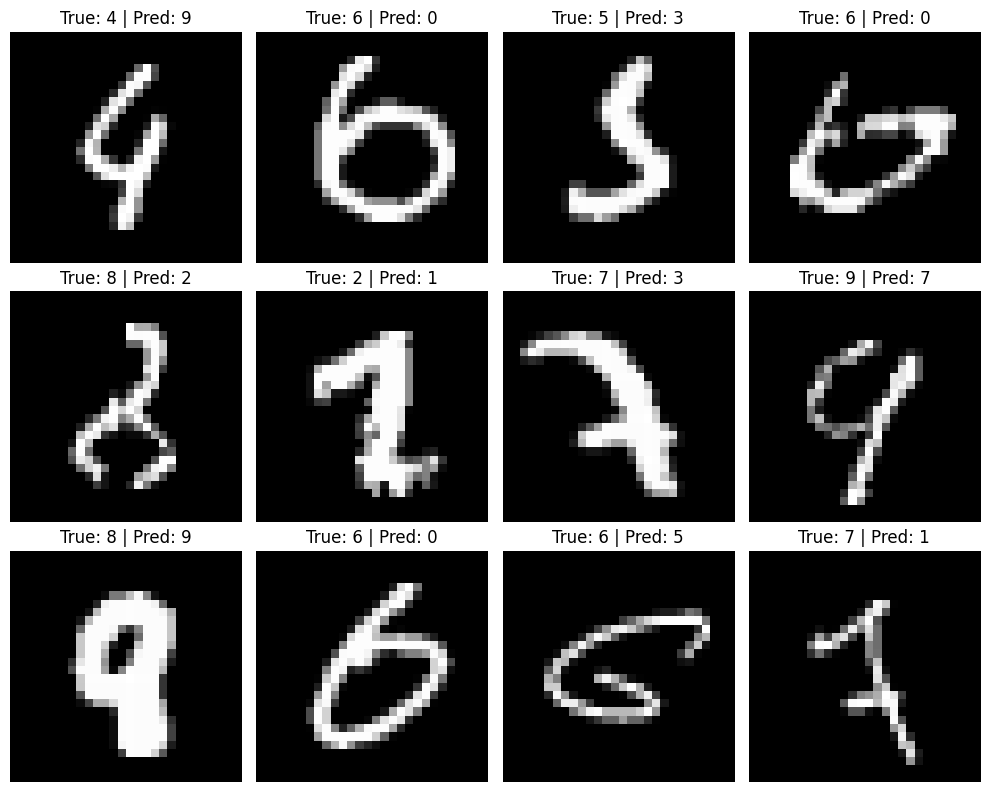

In [29]:
model.eval()

wrong_images = []
wrong_labels = []
wrong_predictions = []

with torch.no_grad():
    for images, labels in test_loader:

        outputs = model(images.to(device))
        predictions = outputs.argmax(dim=1).cpu()

        wrong_mask = predictions != labels

        wrong_images.extend(images[wrong_mask])
        wrong_labels.extend(labels[wrong_mask])
        wrong_predictions.extend(predictions[wrong_mask])

        if len(wrong_images) >= 12:
            break


fig, axes = plt.subplots(3, 4, figsize=(10, 8))

for i, ax in enumerate(axes.flat):

    image = wrong_images[i] * 0.3081 + 0.1307

    ax.imshow(image.squeeze(), cmap="gray")

    ax.set_title(
        f"True: {wrong_labels[i].item()} | "
        f"Pred: {wrong_predictions[i].item()}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()